# AI-Based Crime Scene Analysis — Phase 1 (Complete Notebook)
## Violence Detection: Preprocessing + Training of 3 Models

**Team:** Rameen Babar (Preprocessing) | Rida Fatima (Model Training) | Hamza (Evaluation)

This single notebook covers the full Phase 1 pipeline end-to-end:

1. Dataset exploration (RLVD + SCVD)
2. Frame extraction / preprocessing pipeline
3. Unified metadata + train/val/test split
4. Data generator
5. **3 candidate models**: MobileNetV2+Bi-LSTM, ConvLSTM2D, 3D CNN (C3D-lite)
6. Training all 3 models
7. Saving results for Hamza's evaluation stage

---
> ## ⚠️ IMPORTANT — Run this on Kaggle (you don't need your own GPU)
>
> This notebook is designed to run on **Kaggle Notebooks**, which give you a
> **free GPU (T4 x2)** — you do NOT need a GPU on your own laptop.
>
> **Setup steps on Kaggle:**
> 1. Create a Kaggle account at kaggle.com (free).
> 2. Create a **New Notebook**, then **File → Import Notebook** and upload this file.
> 3. On the right sidebar click **"+ Add Input"** and add both datasets:
>    - `mohamedmustafa/real-life-violence-situations-dataset` (RLVD)
>    - `toluwaniaremu/smartcity-cctv-violence-detection-dataset-scvd` (SCVD)
> 4. On the right sidebar, go to **Settings → Accelerator** and select **GPU T4 x2**.
>    Without this, training will be extremely slow.
> 5. Run all cells top to bottom (**Run → Run All**).
>
> Without a GPU, `EPOCHS` can be reduced (see the config cell) so the
> notebook still finishes — but a Kaggle GPU session is strongly recommended.


## 1. Imports & Environment Setup

In [35]:
# ===== 1. Imports & environment setup =====
import warnings
import os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suppresses TensorFlow C++ warnings

import tensorflow as tf
tf.get_logger().setLevel('ERROR')          # suppresses TF Python-level warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, applications, mixed_precision
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus)
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

# Enable mixed precision (FP16) — speeds up training on T4 / P100 by ~2x
if gpus:
    mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision policy:", mixed_precision.global_policy().name)

if not gpus:
    print("\n⚠️ No GPU detected. On Kaggle, enable it via:")
    print("   Settings (right sidebar) -> Accelerator -> GPU T4 x2")
    print("   Then restart the session and re-run all cells.")

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

NUM_FRAMES = 16
FRAME_SIZE = (224, 224)
BATCH_SIZE = 4   # T4 x2 can handle 8; CPU fallback uses 2
EPOCHS = 9 if gpus else 3      # more epochs with GPU


TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision policy: mixed_float16


## 2. Dataset Paths & Exploration

Update `RLVD_PATH` and `SCVD_PATH` if Kaggle mounts the datasets under
slightly different folder names — check the printed folder tree below and
adjust if needed.


In [36]:
# ===== 2. Dataset paths =====
RLVD_PATH = '/kaggle/input/datasets/mohamedmustafa/real-life-violence-situations-dataset/Real Life Violence Dataset'
SCVD_PATH = '/kaggle/input/datasets/toluwaniaremu/smartcity-cctv-violence-detection-dataset-scvd/SCVD'

# If the paths above don't exist, auto-detect by scanning /kaggle/input
if not os.path.exists(RLVD_PATH) or not os.path.exists(SCVD_PATH):
    print("Default paths not found — scanning /kaggle/input for dataset folders...")
    for root, dirs, files in os.walk('/kaggle/input'):
        depth = root.count(os.sep) - '/kaggle/input'.count(os.sep)
        if depth <= 3:
            print(root)


In [37]:
# ===== 2b. Explore folder structure =====
for name, dataset_path in [('RLVD', RLVD_PATH), ('SCVD', SCVD_PATH)]:
    print(f"\n=== {name}: {dataset_path} ===")
    if not os.path.exists(dataset_path):
        print("  PATH NOT FOUND — update the path above based on the scan output.")
        continue
    for root, dirs, files in os.walk(dataset_path):
        level = root.replace(dataset_path, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        if level < 3:
            subindent = ' ' * 2 * (level + 1)
            for f in files[:3]:
                print(f'{subindent}{f}')



=== RLVD: /kaggle/input/datasets/mohamedmustafa/real-life-violence-situations-dataset/Real Life Violence Dataset ===
Real Life Violence Dataset/
  NonViolence/
    NV_759.mp4
    NV_564.mp4
    NV_126.mp4
  Violence/
    V_465.mp4
    V_313.mp4
    V_753.mp4

=== SCVD: /kaggle/input/datasets/toluwaniaremu/smartcity-cctv-violence-detection-dataset-scvd/SCVD ===
SCVD/
  SCVD_converted_sec_split/
    Test/
      Weaponized/
      Normal/
      Violence/
    Train/
      Weaponized/
      Normal/
      Violence/
  SCVD_converted/
    Test/
      Weaponized/
      Normal/
      Violence/
    Train/
      Weaponized/
      Normal/
      Violence/


## 3. Frame Extraction / Preprocessing Pipeline (Member 1's Logic)

`preprocess_video()` extracts 16 evenly spaced frames from a video,
converts BGR→RGB, resizes to 224x224, and normalizes pixel values to
`[0, 1]`, returning a `(16, 224, 224, 3)` array.


In [39]:
# ===== 3. preprocess_video() =====
def preprocess_video(video_path, output_size=FRAME_SIZE, num_frames=NUM_FRAMES):
    """
    Extract num_frames evenly spaced frames from a video.
    Resize to output_size and normalize to [0, 1].
    Returns numpy array of shape (num_frames, H, W, 3), or None if the
    video could not be read or has fewer than num_frames frames.
    """
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        cap.release()
        return None

    indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, output_size)
        frame = frame / 255.0
        frames.append(frame)

    cap.release()

    if len(frames) < num_frames:
        return None

    return np.array(frames, dtype=np.float32)


Sample video: /kaggle/input/datasets/mohamedmustafa/real-life-violence-situations-dataset/Real Life Violence Dataset/NonViolence/NV_759.mp4
Output shape: (16, 224, 224, 3)
Min value: 0.0 | Max value: 1.0


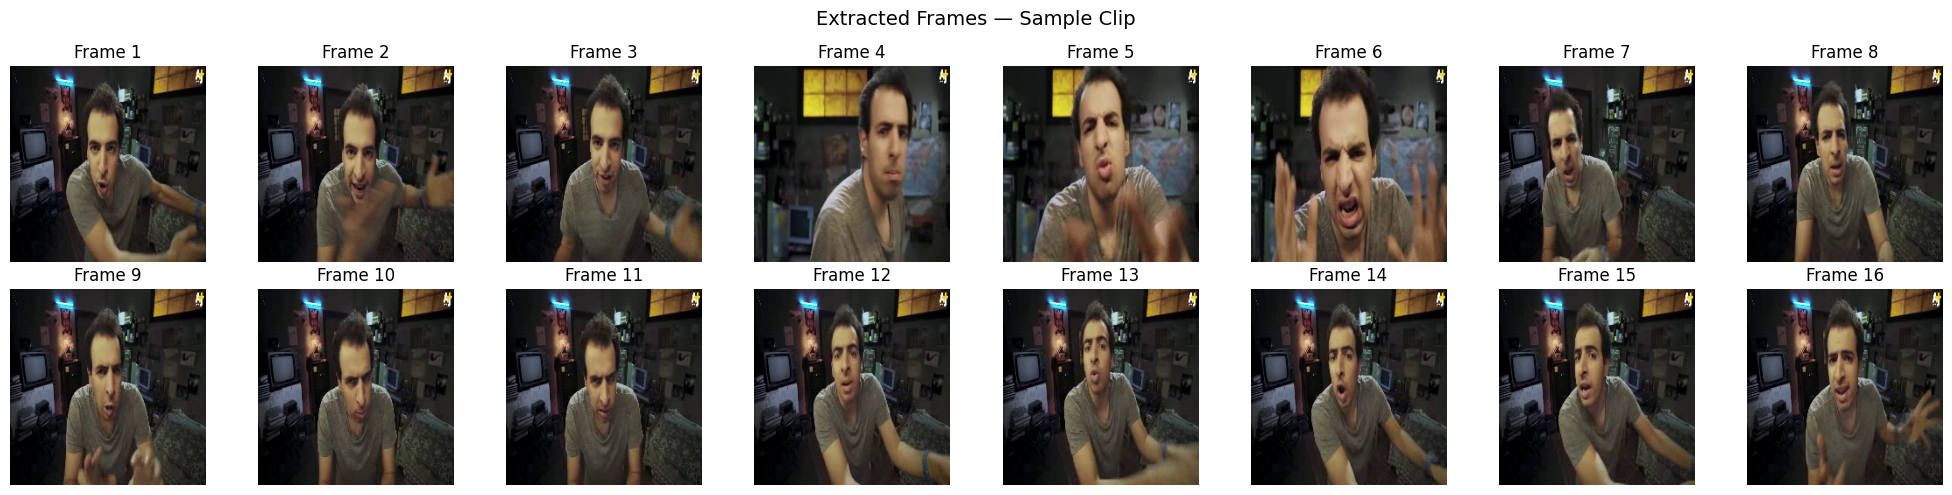

In [40]:
# ===== 3b. Quick sanity check on one sample video =====
def find_first_video(base_path, exts=('.mp4', '.avi')):
    for root, dirs, files in os.walk(base_path):
        for f in files:
            if os.path.splitext(f)[1].lower() in exts:
                return os.path.join(root, f)
    return None

sample_video = find_first_video(RLVD_PATH) or find_first_video(SCVD_PATH)
print("Sample video:", sample_video)

if sample_video:
    sample_frames = preprocess_video(sample_video)
    if sample_frames is not None:
        print("Output shape:", sample_frames.shape)
        print("Min value:", sample_frames.min(), "| Max value:", sample_frames.max())

        # Visualize the 16 extracted frames
        fig, axes = plt.subplots(2, 8, figsize=(20, 5))
        fig.suptitle("Extracted Frames — Sample Clip", fontsize=14)
        for i, ax in enumerate(axes.flat):
            ax.imshow(sample_frames[i])
            ax.axis('off')
            ax.set_title(f"Frame {i+1}")
        plt.tight_layout()
        plt.show()
    else:
        print("Could not extract frames from sample video.")


## 4. Build Unified Metadata Across Both Datasets

- RLVD has a **flat** structure: `RLVD_PATH/ClassName/video.mp4`
- SCVD has a **split** structure: `SCVD_PATH/Split/ClassName/video.avi`

Both are merged into one DataFrame `df` with columns:
`dataset`, `split`, `class`, `filepath`, plus a unified binary `label`
(0 = Non-Violence, 1 = Violence).


In [41]:
# ===== 4. Build metadata =====
VIDEO_EXTENSIONS = {'.mp4', '.avi'}

def build_metadata(dataset_name, base_path, structure='flat'):
    """
    structure='flat'  -> base_path/ClassName/video.mp4   (RLVD)
    structure='split' -> base_path/Split/ClassName/video.avi (SCVD)
    """
    records = []

    if not os.path.exists(base_path):
        print(f"WARNING: path not found for {dataset_name}: {base_path}")
        return records

    if structure == 'flat':
        for cls in os.listdir(base_path):
            cls_path = os.path.join(base_path, cls)
            if not os.path.isdir(cls_path):
                continue
            for f in os.listdir(cls_path):
                if os.path.splitext(f)[1].lower() in VIDEO_EXTENSIONS:
                    records.append({
                        'dataset': dataset_name,
                        'split': 'train',  # RLVD has no predefined split
                        'class': cls,
                        'filepath': os.path.join(cls_path, f)
                    })

    elif structure == 'split':
        for split in os.listdir(base_path):
            split_path = os.path.join(base_path, split)
            if not os.path.isdir(split_path):
                continue
            for cls in os.listdir(split_path):
                cls_path = os.path.join(split_path, cls)
                if not os.path.isdir(cls_path):
                    continue
                for f in os.listdir(cls_path):
                    if os.path.splitext(f)[1].lower() in VIDEO_EXTENSIONS:
                        records.append({
                            'dataset': dataset_name,
                            'split': split.lower(),
                            'class': cls,
                            'filepath': os.path.join(cls_path, f)
                        })

    return records


rlvd_records = build_metadata('RLVD', RLVD_PATH, structure='flat')
scvd_records = build_metadata('SCVD', SCVD_PATH, structure='split')

all_records = rlvd_records + scvd_records
df = pd.DataFrame(all_records)

print("Total videos indexed:", len(df))
print("\nBreakdown by dataset / split / class:")
print(df.groupby(['dataset', 'split', 'class']).size().to_string())


Total videos indexed: 2000

Breakdown by dataset / split / class:
dataset  split  class      
RLVD     train  NonViolence    1000
                Violence       1000


In [42]:
# ===== 4b. Unify class labels to binary =====
def to_binary_label(cls_name):
    cls_name = str(cls_name).strip().lower()
    if 'non' in cls_name:          # 'NonViolence', 'non_violence', etc.
        return 0
    return 1                       # 'Violence', 'Weaponized', 'Fight', etc.

df['label'] = df['class'].apply(to_binary_label)

print(df['label'].value_counts())
df.to_csv('dataset_metadata.csv', index=False)
print("\nSaved unified metadata to dataset_metadata.csv")


label
0    1000
1    1000
Name: count, dtype: int64

Saved unified metadata to dataset_metadata.csv


In [43]:
# ===== 4c. Pipeline validation — test preprocessing on one sample per class =====
val_results = []
for (dataset, split, cls), group in df.groupby(['dataset', 'split', 'class']):
    sample_path = group['filepath'].iloc[0]
    frames = preprocess_video(sample_path)
    status = 'OK' if frames is not None else 'FAILED'
    val_results.append({
        'dataset': dataset, 'split': split, 'class': cls,
        'sample_file': os.path.basename(sample_path), 'status': status
    })
    print(f"{dataset} | {split} | {cls} -> {status}")

print("\nAll checks done.")


RLVD | train | NonViolence -> OK
RLVD | train | Violence -> OK

All checks done.


## 5. Train / Validation / Test Split

A single stratified split (by binary label) shared across all 3 team
members, so Hamza evaluates every model on the exact same held-out test set.


In [45]:
# ===== 5. Train/Val/Test split =====
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED
)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)


Train: 1400 Val: 300 Test: 300


## 6. Video Data Generator

Decodes frames on-the-fly (videos are too large to hold fully in RAM).


In [46]:
# ===== 6. Data generator =====
class VideoDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataframe, batch_size=BATCH_SIZE, shuffle=True):
        self.df        = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle   = shuffle
        self.indices   = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return max(1, int(np.ceil(len(self.df) / self.batch_size)))

    def __getitem__(self, idx, _depth=0):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        X, y = [], []
        for i in batch_idx:
            row    = self.df.iloc[i]
            frames = preprocess_video(row['filepath'])
            if frames is None:
                continue
            X.append(frames)
            y.append(row['label'])

        if len(X) == 0:
            # Guard against infinite recursion
            if _depth >= len(self):
                dummy = np.zeros((1, NUM_FRAMES, *FRAME_SIZE, 3), dtype=np.float32)
                return dummy, np.zeros((1,), dtype=np.float32)
            next_idx = (idx + 1) % len(self)
            return self.__getitem__(next_idx, _depth=_depth + 1)

        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


train_gen = VideoDataGenerator(train_df, batch_size=BATCH_SIZE, shuffle=True)
val_gen   = VideoDataGenerator(val_df,   batch_size=BATCH_SIZE, shuffle=False)
test_gen  = VideoDataGenerator(test_df,  batch_size=BATCH_SIZE, shuffle=False)
print(f"Train batches: {len(train_gen)} | Val batches: {len(val_gen)} | Test batches: {len(test_gen)}")


Train batches: 350 | Val batches: 75 | Test batches: 75


## 7. Class Weights (handle Violence / Non-Violence imbalance)

In [47]:
# ===== 7. Class weights =====
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}
print("Class weights:", class_weight_dict)


Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


## 8. Model 2 — ConvLSTM2D (end-to-end spatiotemporal)

No pretrained backbone — `ConvLSTM2D` layers learn spatial AND temporal
features jointly from raw frames. Frames are resized to 96x96 internally to
keep memory usage manageable.


In [48]:
# ===== 9. Model 2: ConvLSTM2D =====
CONVLSTM_SIZE = (96, 96)   # downsized for memory efficiency

def build_convlstm(input_shape=(NUM_FRAMES, *FRAME_SIZE, 3)):
    inputs = layers.Input(shape=input_shape)

    # Resize each frame to the smaller ConvLSTM resolution
    x = layers.TimeDistributed(
        layers.Resizing(CONVLSTM_SIZE[0], CONVLSTM_SIZE[1])
    )(inputs)

    x = layers.ConvLSTM2D(32, (3, 3), padding='same', return_sequences=True,
                           activation='tanh')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling3D((1, 2, 2))(x)

    x = layers.ConvLSTM2D(64, (3, 3), padding='same', return_sequences=False,
                           activation='tanh')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Flatten()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    # Cast to float32 before sigmoid — required for mixed_float16 stability
    x = layers.Dense(1, dtype='float32')(x)
    outputs = layers.Activation('sigmoid', dtype='float32')(x)

    model = models.Model(inputs, outputs, name="ConvLSTM2D_Model")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

model_2 = build_convlstm(input_shape=(NUM_FRAMES, *FRAME_SIZE, 3))
model_2.summary()


Model: "ConvLSTM2D_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 16, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 16, 96, 96, 3)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_4 (ConvLSTM2D)      │ (None, 16, 96, 96, 32) │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 96, 96, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 16, 48, 48, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_5 (ConvLSTM2D)      │ (None, 48, 48, 64)     │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     2,359,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,697 (10.00 MB)

 Trainable params: 2,621,505 (10.00 MB)

 Non-trainable params: 192 (768.00 B)

In [49]:
# ===== 11. Shared callbacks =====
def get_callbacks(model_name):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc', mode='max', patience=5,
            restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=2,
            min_lr=1e-7, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f"best_{model_name}.keras",   # .keras format (TF2 standard)
            monitor='val_auc', mode='max', save_best_only=True,
            verbose=1
        ),
    ]


In [50]:
# ===== 12. Shared results dictionary =====
results = {}
print("Results dict initialised. Starting training...")


Results dict initialised. Starting training...


In [51]:
# ===== 13b. Train & save Model 2: ConvLSTM2D =====
print("========== Training ConvLSTM2D ==========")
history_2 = model_2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=get_callbacks("ConvLSTM2D"),
    verbose=1
)
results["ConvLSTM2D"] = history_2.history
model_2.save("final_ConvLSTM2D.keras")
np.save("training_histories.npy", results, allow_pickle=True)
print("Saved final_ConvLSTM2D.keras + updated training_histories.npy")


========== Training ConvLSTM2D ==========
Epoch 1/9
179/350 ━━━━━━━━━━━━━━━━━━━━ 7:29 3s/step - accuracy: 0.6320 - auc: 0.6770 - loss: 0.9708

[h264 @ 0x7b9590107980] mb_type 104 in P slice too large at 98 31
[h264 @ 0x7b9590107980] error while decoding MB 98 31
[h264 @ 0x7b9590107980] mb_type 104 in P slice too large at 98 31
[h264 @ 0x7b9590107980] error while decoding MB 98 31
[h264 @ 0x7b9590107980] mb_type 104 in P slice too large at 98 31
[h264 @ 0x7b9590107980] error while decoding MB 98 31


350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6737 - auc: 0.7263 - loss: 0.8276
Epoch 1: val_auc improved from None to 0.90450, saving model to best_ConvLSTM2D.keras

Epoch 1: finished saving model to best_ConvLSTM2D.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 1100s 3s/step - accuracy: 0.7396 - auc: 0.8070 - loss: 0.6121 - val_accuracy: 0.7826 - val_auc: 0.9045 - val_loss: 0.4634 - learning_rate: 1.0000e-04
Epoch 2/9
219/350 ━━━━━━━━━━━━━━━━━━━━ 5:23 2s/step - accuracy: 0.8585 - auc: 0.9314 - loss: 0.3373

[h264 @ 0x7b95bc054e40] mb_type 104 in P slice too large at 98 31
[h264 @ 0x7b95bc054e40] error while decoding MB 98 31
[h264 @ 0x7b95bc054e40] mb_type 104 in P slice too large at 98 31
[h264 @ 0x7b95bc054e40] error while decoding MB 98 31
[h264 @ 0x7b95bc054e40] mb_type 104 in P slice too large at 98 31
[h264 @ 0x7b95bc054e40] error while decoding MB 98 31


350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8620 - auc: 0.9357 - loss: 0.3282
Epoch 2: val_auc improved from 0.90450 to 0.94624, saving model to best_ConvLSTM2D.keras

Epoch 2: finished saving model to best_ConvLSTM2D.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 1059s 3s/step - accuracy: 0.8584 - auc: 0.9390 - loss: 0.3233 - val_accuracy: 0.8495 - val_auc: 0.9462 - val_loss: 0.3283 - learning_rate: 1.0000e-04
Epoch 3/9
170/350 ━━━━━━━━━━━━━━━━━━━━ 7:45 3s/step - accuracy: 0.9075 - auc: 0.9681 - loss: 0.2319

...

350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9960 - auc: 0.9998 - loss: 0.0236
Epoch 7: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 7: val_auc improved from 0.96555 to 0.96660, saving model to best_ConvLSTM2D.keras

Epoch 7: finished saving model to best_ConvLSTM2D.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 1063s 3s/step - accuracy: 0.9936 - auc: 0.9997 - loss: 0.0293 - val_accuracy: 0.9030 - val_auc: 0.9666 - val_loss: 0.3065 - learning_rate: 5.0000e-05
Epoch 8/9
133/350 ━━━━━━━━━━━━━━━━━━━━ 9:04 3s/step - accuracy: 0.9996 - auc: 1.0000 - loss: 0.0131

[h264 @ 0x33b448c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x33b448c0] error while decoding MB 98 31
[h264 @ 0x33b448c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x33b448c0] error while decoding MB 98 31
[h264 @ 0x33b448c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x33b448c0] error while decoding MB 98 31


350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9973 - auc: 0.9999 - loss: 0.0183
Epoch 8: val_auc improved from 0.96660 to 0.97188, saving model to best_ConvLSTM2D.keras

Epoch 8: finished saving model to best_ConvLSTM2D.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 1068s 3s/step - accuracy: 0.9950 - auc: 0.9998 - loss: 0.0231 - val_accuracy: 0.9130 - val_auc: 0.9719 - val_loss: 0.2536 - learning_rate: 2.5000e-05
Epoch 9/9
260/350 ━━━━━━━━━━━━━━━━━━━━ 3:42 2s/step - accuracy: 0.9933 - auc: 1.0000 - loss: 0.0208

[h264 @ 0x7b958004bf80] mb_type 104 in P slice too large at 98 31
[h264 @ 0x7b958004bf80] error while decoding MB 98 31
[h264 @ 0x7b958004bf80] mb_type 104 in P slice too large at 98 31
[h264 @ 0x7b958004bf80] error while decoding MB 98 31
[h264 @ 0x7b958004bf80] mb_type 104 in P slice too large at 98 31
[h264 @ 0x7b958004bf80] error while decoding MB 98 31


350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9942 - auc: 1.0000 - loss: 0.0199
Epoch 9: val_auc did not improve from 0.97188
350/350 ━━━━━━━━━━━━━━━━━━━━ 1058s 3s/step - accuracy: 0.9964 - auc: 1.0000 - loss: 0.0181 - val_accuracy: 0.9130 - val_auc: 0.9683 - val_loss: 0.2599 - learning_rate: 2.5000e-05
Restoring model weights from the end of the best epoch: 8.
Saved final_ConvLSTM2D.keras + updated training_histories.npy
